In [1]:
import os
import sys
import json
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.detector import DeepfakeDetector
from src.evaluate import evaluate_dataset, compute_metrics
from src.visualize import (
    plot_roc_curve,
    plot_score_distribution,
    plot_confusion_matrix,
    plot_comparison_bar,
    visualize_samples,
)

WEIGHTS_PATH = ROOT / 'weights' / 'sbi_efficientb4.pth'
FF_MANIFEST = ROOT / 'data' / 'cache' / 'ff++' / 'manifest.json'
CELEB_MANIFEST = ROOT / 'data' / 'cache' / 'celebdf' / 'manifest.json'
RESULTS_DIR = ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cpu


In [2]:
detector = DeepfakeDetector(str(WEIGHTS_PATH))

dummy = torch.zeros(1, 3, 224, 224)
dummy_score = detector.predict_image(dummy)
print(f'Dummy forward pass score: {dummy_score:.4f}')

[detector] Backbone: efficientnet-b4 (efficientnet_pytorch, num_classes=2)
[detector] Parameters: 17.55M
[detector] Device: cpu
Dummy forward pass score: 0.7073


In [3]:
def manifest_stats(manifest_path):
    with open(manifest_path, 'r', encoding='utf-8') as f:
        m = json.load(f)
    n_real = sum(1 for v in m if v['label'] == 0)
    n_fake = sum(1 for v in m if v['label'] == 1)
    n_frames = sum(len(v['frames']) for v in m)
    return {
        'videos': len(m),
        'real': n_real,
        'fake': n_fake,
        'frames': n_frames,
        'manifest': m,
    }

ff_stats = manifest_stats(FF_MANIFEST)
celeb_stats = manifest_stats(CELEB_MANIFEST)

print('FaceForensics++ (test split)')
print(f"  videos: {ff_stats['videos']} | real: {ff_stats['real']} | fake: {ff_stats['fake']} | frames: {ff_stats['frames']}")
print('Celeb-DF v2 (official test split)')
print(f"  videos: {celeb_stats['videos']} | real: {celeb_stats['real']} | fake: {celeb_stats['fake']} | frames: {celeb_stats['frames']}")

FaceForensics++ (test split)
  videos: 193 | real: 40 | fake: 153 | frames: 9073
Celeb-DF v2 (official test split)
  videos: 448 | real: 108 | fake: 340 | frames: 17187


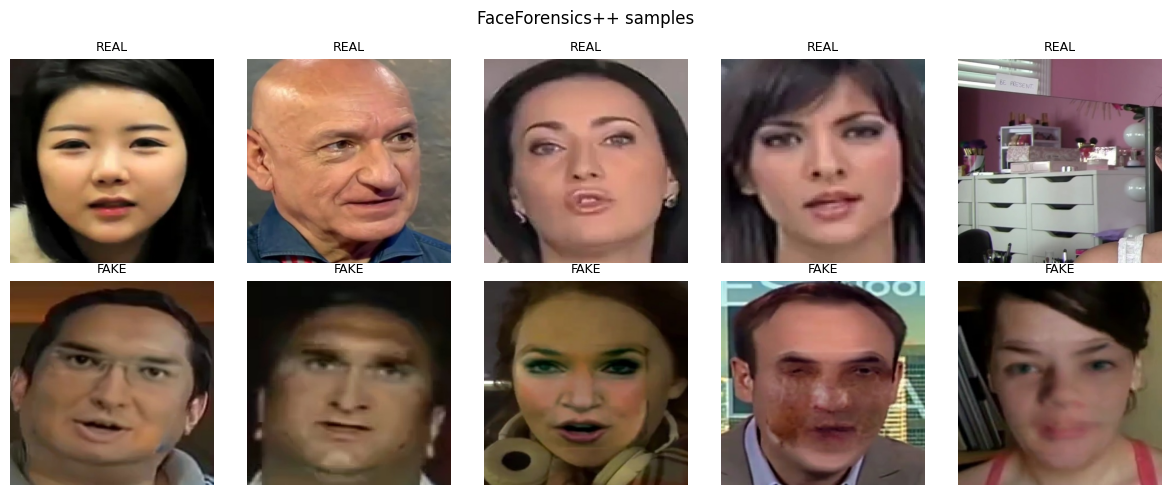

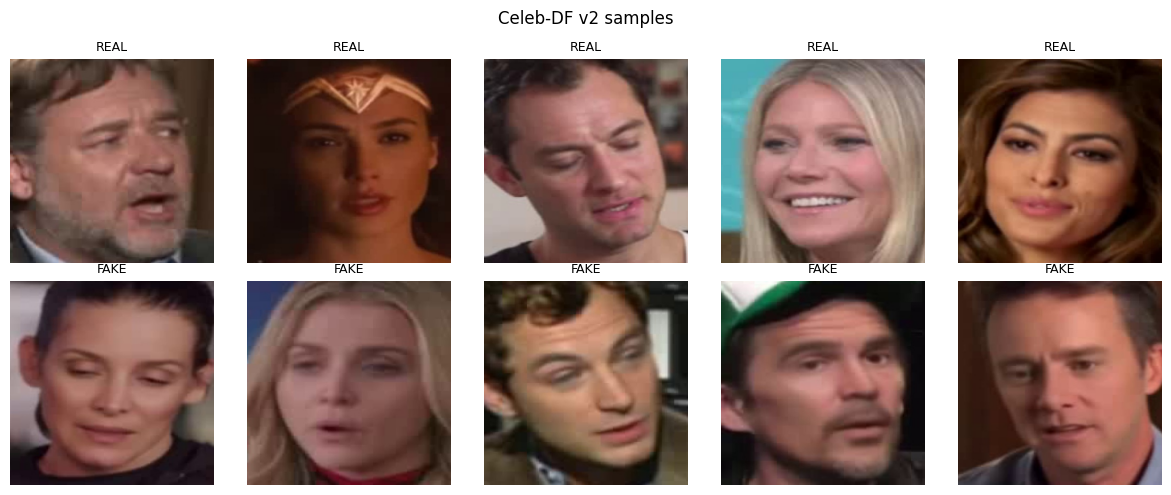

In [4]:
def show_sample_grid(stats, title):
    reals = [v for v in stats['manifest'] if v['label'] == 0 and v['frames']]
    fakes = [v for v in stats['manifest'] if v['label'] == 1 and v['frames']]
    random.shuffle(reals)
    random.shuffle(fakes)
    reals = reals[:5]
    fakes = fakes[:5]

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i, v in enumerate(reals):
        axes[0, i].imshow(Image.open(v['frames'][0]).convert('RGB'))
        axes[0, i].set_title('REAL', fontsize=9)
        axes[0, i].axis('off')
    for i, v in enumerate(fakes):
        axes[1, i].imshow(Image.open(v['frames'][0]).convert('RGB'))
        axes[1, i].set_title('FAKE', fontsize=9)
        axes[1, i].axis('off')
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

show_sample_grid(ff_stats, 'FaceForensics++ samples')
show_sample_grid(celeb_stats, 'Celeb-DF v2 samples')

Inference on ff++: 100%|██████████| 193/193 [23:46<00:00,  7.39s/it]


[detector] Wrote predictions -> results\ff++_predictions.json

=== Results on ff++ ===
Metric            Value
------------------------
AUC              0.9910
Accuracy         0.8135
F1               0.8667
Precision        1.0000
Recall           0.7647
EER              0.0321

[evaluate] Wrote metrics -> results\ff++_metrics.json


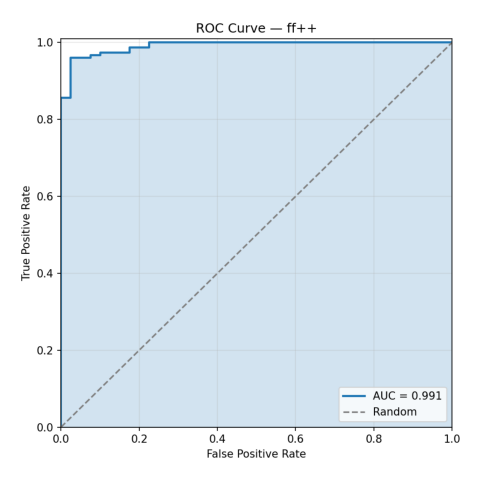

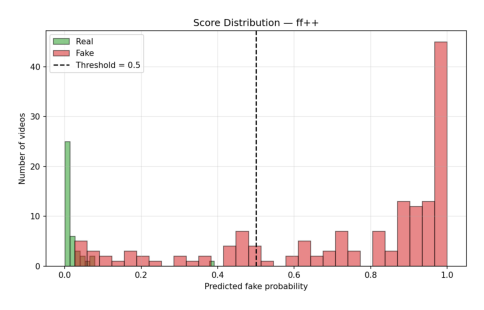

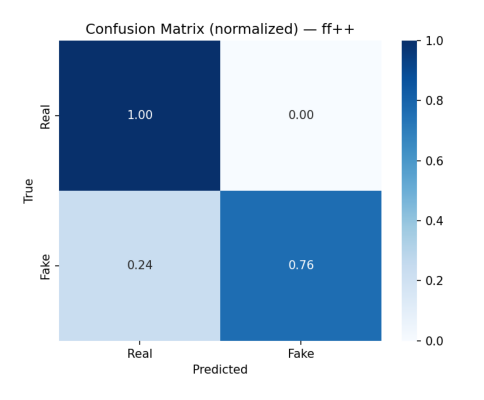

In [5]:
ff_metrics, ff_predictions = evaluate_dataset(detector, str(FF_MANIFEST), 'ff++')

y_true_ff = [p['true_label'] for p in ff_predictions]
y_scores_ff = [p['pred_score'] for p in ff_predictions]
y_pred_ff = [p['pred_label'] for p in ff_predictions]

roc_path = plot_roc_curve(y_true_ff, y_scores_ff, 'ff++')
dist_path = plot_score_distribution(y_true_ff, y_scores_ff, 'ff++')
cm_path = plot_confusion_matrix(y_true_ff, y_pred_ff, 'ff++')

for path in (roc_path, dist_path, cm_path):
    display_img = Image.open(path)
    plt.figure(figsize=(6, 6))
    plt.imshow(display_img)
    plt.axis('off')
    plt.show()

Inference on celebdf: 100%|██████████| 448/448 [49:51<00:00,  6.68s/it]


[detector] Wrote predictions -> results\celebdf_predictions.json

=== Results on celebdf ===
Metric            Value
------------------------
AUC              0.9186
Accuracy         0.7366
F1               0.7958
Precision        0.9664
Recall           0.6765
EER              0.1520

[evaluate] Wrote metrics -> results\celebdf_metrics.json


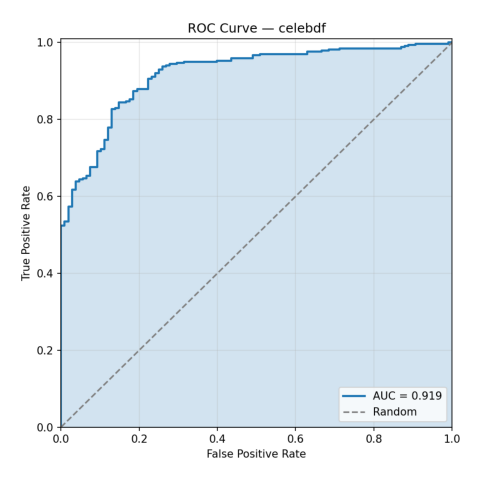

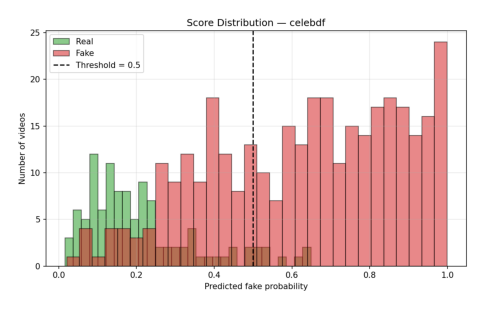

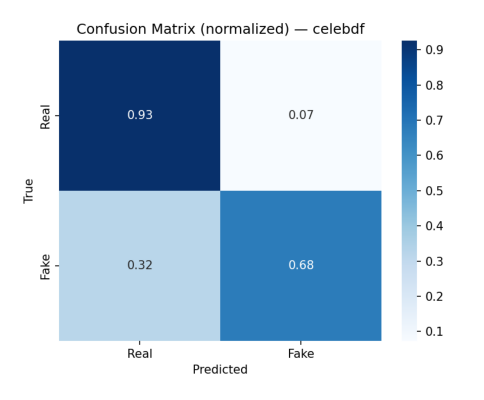

In [6]:
celeb_metrics, celeb_predictions = evaluate_dataset(detector, str(CELEB_MANIFEST), 'celebdf')

y_true_c = [p['true_label'] for p in celeb_predictions]
y_scores_c = [p['pred_score'] for p in celeb_predictions]
y_pred_c = [p['pred_label'] for p in celeb_predictions]

roc_path = plot_roc_curve(y_true_c, y_scores_c, 'celebdf')
dist_path = plot_score_distribution(y_true_c, y_scores_c, 'celebdf')
cm_path = plot_confusion_matrix(y_true_c, y_pred_c, 'celebdf')

for path in (roc_path, dist_path, cm_path):
    display_img = Image.open(path)
    plt.figure(figsize=(6, 6))
    plt.imshow(display_img)
    plt.axis('off')
    plt.show()

Metric              FF++   Celeb-DF v2         Δ
------------------------------------------------
AUC               0.9910        0.9186    0.0724
Accuracy          0.8135        0.7366    0.0769
F1                0.8667        0.7958    0.0708
Precision         1.0000        0.9664    0.0336
Recall            0.7647        0.6765    0.0882
EER               0.0321        0.1520   -0.1199


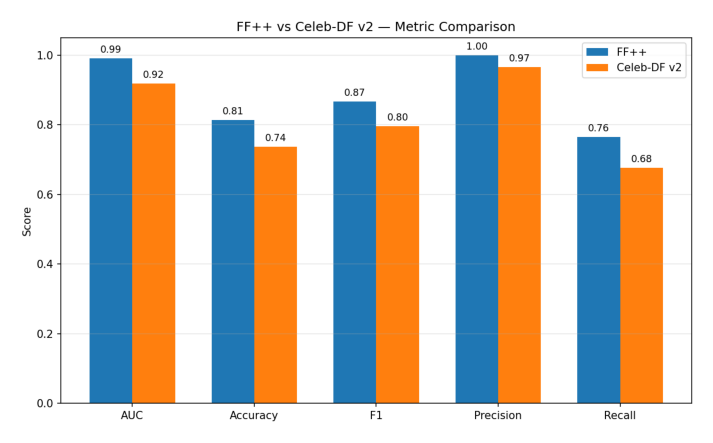

In [7]:
header = f"{'Metric':<12}{'FF++':>12}{'Celeb-DF v2':>14}{'Δ':>10}"
print(header)
print('-' * len(header))
for m in ('AUC', 'Accuracy', 'F1', 'Precision', 'Recall', 'EER'):
    delta = ff_metrics[m] - celeb_metrics[m]
    print(f"{m:<12}{ff_metrics[m]:>12.4f}{celeb_metrics[m]:>14.4f}{delta:>10.4f}")

bar_path = plot_comparison_bar(ff_metrics, celeb_metrics)
plt.figure(figsize=(9, 5.5))
plt.imshow(Image.open(bar_path))
plt.axis('off')
plt.show()

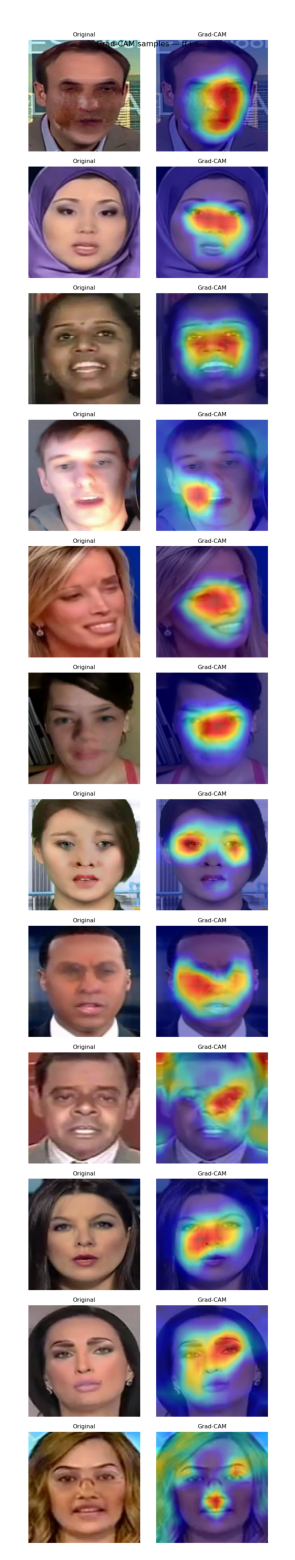

In [8]:
ff_gradcam_path = visualize_samples(
    detector, str(FF_MANIFEST), 'ff++',
    n_correct=8, n_wrong=4, predictions=ff_predictions,
)
plt.figure(figsize=(8, 20))
plt.imshow(Image.open(ff_gradcam_path))
plt.axis('off')
plt.show()

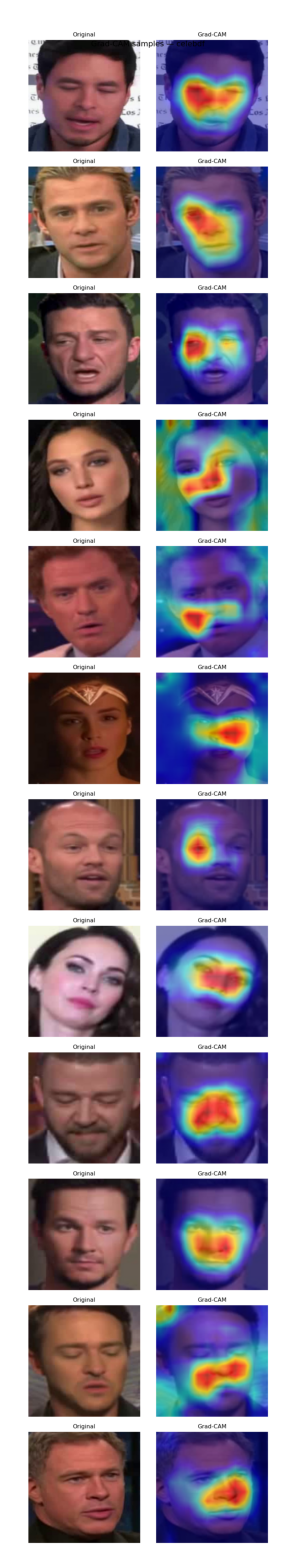

In [9]:
celeb_gradcam_path = visualize_samples(
    detector, str(CELEB_MANIFEST), 'celebdf',
    n_correct=8, n_wrong=4, predictions=celeb_predictions,
)
plt.figure(figsize=(8, 20))
plt.imshow(Image.open(celeb_gradcam_path))
plt.axis('off')
plt.show()

In [10]:
wrong_reals = sorted(
    [p for p in ff_predictions if p['true_label'] == 0 and p['pred_label'] == 1],
    key=lambda p: p['pred_score'], reverse=True,
)[:5]

wrong_fakes = sorted(
    [p for p in ff_predictions if p['true_label'] == 1 and p['pred_label'] == 0],
    key=lambda p: p['pred_score'],
)[:5]

print('Top-5 REAL-predicted-FAKE (false positives):')
for p in wrong_reals:
    print(f"  {p['video_name']:<30} score={p['pred_score']:.3f}")
print()
print('Top-5 FAKE-predicted-REAL (false negatives):')
for p in wrong_fakes:
    print(f"  {p['video_name']:<30} score={p['pred_score']:.3f}")

Top-5 REAL-predicted-FAKE (false positives):

Top-5 FAKE-predicted-REAL (false negatives):
  929_962                        score=0.026
  929_962                        score=0.026
  896_128                        score=0.033
  896_128                        score=0.033
  862_047                        score=0.043


No samples for: False Positives — REAL videos predicted FAKE


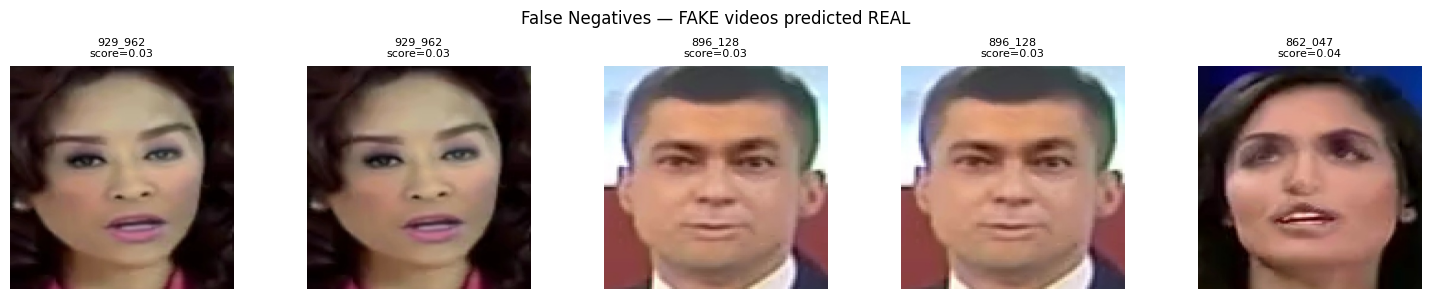

In [11]:
def show_error_row(samples, title):
    if not samples:
        print(f'No samples for: {title}')
        return
    fig, axes = plt.subplots(1, len(samples), figsize=(3 * len(samples), 3))
    if len(samples) == 1:
        axes = [axes]
    for ax, p in zip(axes, samples):
        if not p.get('frames'):
            ax.axis('off')
            continue
        ax.imshow(Image.open(p['frames'][0]).convert('RGB'))
        ax.set_title(f"{p['video_name']}\nscore={p['pred_score']:.2f}", fontsize=8)
        ax.axis('off')
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

show_error_row(wrong_reals, 'False Positives — REAL videos predicted FAKE')
show_error_row(wrong_fakes, 'False Negatives — FAKE videos predicted REAL')

In [12]:
print(f"{'Metric':<12}{'FF++':>12}{'Celeb-DF v2':>14}")
print('-' * 38)
for m in ('AUC', 'Accuracy', 'F1', 'Precision', 'Recall', 'EER'):
    print(f"{m:<12}{ff_metrics[m]:>12.4f}{celeb_metrics[m]:>14.4f}")

Metric              FF++   Celeb-DF v2
--------------------------------------
AUC               0.9910        0.9186
Accuracy          0.8135        0.7366
F1                0.8667        0.7958
Precision         1.0000        0.9664
Recall            0.7647        0.6765
EER               0.0321        0.1520
